# Ocean-Submerged Data Center — Ecological & Financial Feasibility

**Hypothetical:** a 5 MW submerged data center on the seabed of Puget Sound, ~15 km from Seattle, WA (temperate waters, major metro, 40 m depth).

**Question:** does it make sense — ecologically and financially — to put a data center in the ocean?

**Method:**
1. Assumptions
2. Site & ocean thermal environment
3. Cooling / energy model (subsea vs land baseline)
4. Ecological impact (thermal plume, water use, carbon, habitat)
5. Financial analysis (CAPEX, OPEX, 20-yr NPV, sensitivity)
6. Verdict

Reference anchor: Microsoft Project Natick (2018–2020, Orkney) demonstrated a sealed subsea pod with PUE ≈ 1.07 and ~1/8 the server failure rate of a land facility.

## 1. Assumptions

**Site**
- Puget Sound, Washington — temperate, ~15 km offshore Seattle, seabed depth 40 m
- Bottom water 8–11 °C year-round; tidal currents 0.2–0.5 m/s (natural plume dilution)
- Shore cable landing + grid interconnect within 15 km

**Facility**
- 5 MW IT load, 24/7 (industry-average colocation size), 500 racks @ 10 kW average
- 6 sealed pressure-vessel pods (~0.85 MW each), nitrogen atmosphere, Natick-style
- Design life 20 yr; pods retrieved for service every 5 yr; servers run-to-failure between services

**Engineering**
- Subsea PUE 1.06 (free seawater cooling, small pumping overhead)
- Land baseline PUE 1.40 (air-cooled with evaporative assist)
- Discharge: multiport diffuser, cooling seawater ΔT = 6 °C at discharge
- Regulatory limit (WA industrial-discharge analog): ≤ 3 °C rise at edge of 100 m mixing zone

**Economics**
- Electricity $0.11/kWh (PNW, hydro-heavy), grid carbon 0.25 tCO₂/MWh
- Land DC CAPEX $12M/MW; subsea CAPEX premium +25% (pods, cable landing, marine install)
- Marine service event $2.5M per retrieval (vessel + ROV); annual ROV inspection $150k
- Water + sewer $4/m³; discount rate 8%; 20-yr evaluation

**Ecology (qualitative inputs)**
- No dredging after install; gravity base, no driven piles
- Artificial-reef effect counted as a modest positive (Natick pods were colonized quickly)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

P = {
    # Facility
    'it_load_mw': 5.0,
    'racks': 500,
    'rack_kw': 10.0,
    'pue_subsea': 1.06,
    'pue_land': 1.40,
    'wue_land_L_per_kwh': 1.8,
    # Site / thermal
    'depth_m': 40,
    'discharge_dT_C': 6.0,      # seawater dT across heat exchanger
    'mixing_limit_C': 3.0,      # allowed dT at mixing-zone edge
    'mixing_zone_m': 100,
    'cp_seawater': 3993.0,      # J/(kg*K)
    'rho_seawater': 1025.0,     # kg/m3
    # Economics
    'elec_price_kwh': 0.11,
    'grid_co2_t_per_mwh': 0.25,
    'capex_land_per_mw': 12e6,
    'capex_subsea_premium': 0.25,
    'service_event_cost': 2.5e6,   # every 5 yr
    'rov_annual': 150e3,
    'insurance_premium_annual': 200e3,
    'water_price_m3': 4.0,
    'discount': 0.08,
    'years': 20,
}

it_kw = P['it_load_mw'] * 1000
print(f"Facility: {P['it_load_mw']} MW IT | {P['racks']} racks @ {P['rack_kw']} kW")
print(f"Annual IT energy: {it_kw*8760/1000:,.0f} MWh/yr")

Facility: 5.0 MW IT | 500 racks @ 10.0 kW
Annual IT energy: 43,800 MWh/yr


## 2. Site & ocean thermal environment

Puget Sound representative monthly temperatures (NOAA / Puget Sound Partnership long-term averages). At 40 m depth the seasonal swing is damped to ~2 °C — the cooling resource is essentially constant, which is the core reason to go subsea.

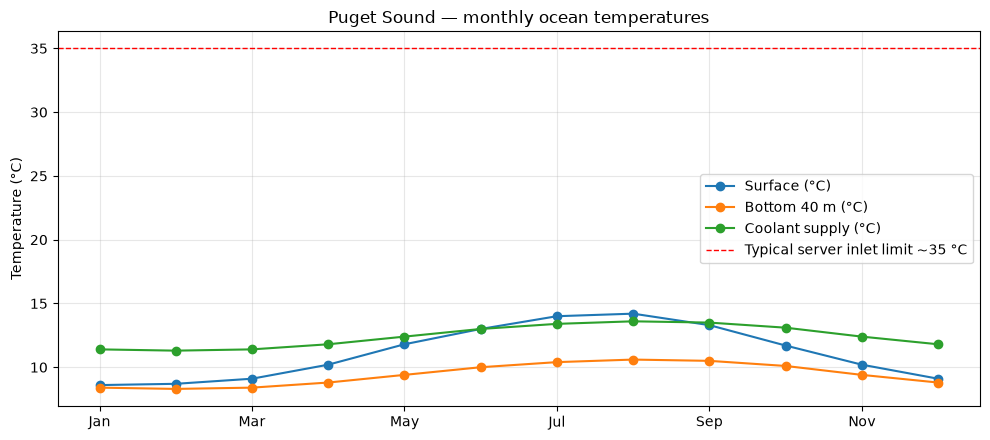

Bottom temp range: 8.3–10.6 °C (Δ 2.3 °C)
Max coolant supply: 13.6 °C — 21.4 °C margin to inlet limit


In [2]:
months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
t_surface = [8.6, 8.7, 9.1, 10.2, 11.8, 13.0, 14.0, 14.2, 13.3, 11.7, 10.2, 9.1]
t_bottom  = [8.4, 8.3, 8.4, 8.8,  9.4, 10.0, 10.4, 10.6, 10.5, 10.1,  9.4, 8.8]
coolant_supply = [t + 3 for t in t_bottom]  # heat-exchanger approach ~3 °C

df = pd.DataFrame({'Surface (°C)': t_surface,
                   'Bottom 40 m (°C)': t_bottom,
                   'Coolant supply (°C)': coolant_supply}, index=months)

ax = df.plot(marker='o', figsize=(10, 4.5))
ax.axhline(35, color='r', ls='--', lw=1, label='Typical server inlet limit ~35 °C')
ax.set_ylabel('Temperature (°C)')
ax.set_title('Puget Sound — monthly ocean temperatures')
ax.grid(alpha=0.3); ax.legend()
plt.tight_layout(); plt.show()

print(f"Bottom temp range: {min(t_bottom)}–{max(t_bottom)} °C (Δ {max(t_bottom)-min(t_bottom):.1f} °C)")
print(f"Max coolant supply: {max(coolant_supply):.1f} °C — {35-max(coolant_supply):.1f} °C margin to inlet limit")

## 3. Cooling & energy model

All IT power ultimately becomes heat. Subsea: rejected directly to seawater via heat exchangers; overhead is seawater pumps + pod auxiliaries. Land baseline: chillers/CRAH units plus evaporation. Compare annual facility energy.

Heat to ocean:         5.30 MW
Seawater flow @6°C ΔT: 221 kg/s = 216 L/s
Seawater pumping:      43 kW (0.9% of IT load)


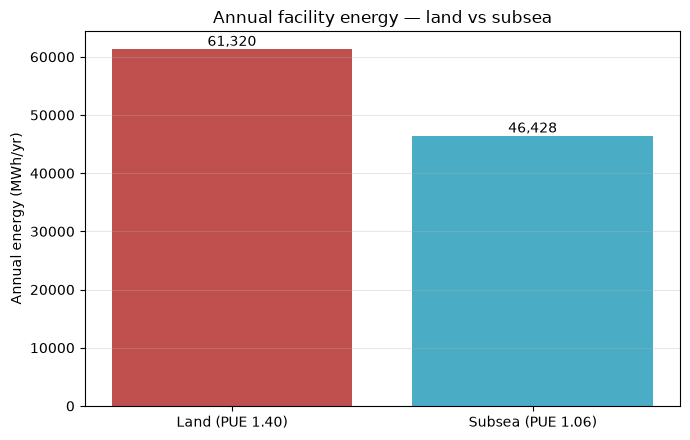

Energy saved: 14,892 MWh/yr (24% of land facility energy)


In [3]:
it_mwh = P['it_load_mw'] * 8760                      # MWh/yr
subsea_mwh = it_mwh * P['pue_subsea']
land_mwh   = it_mwh * P['pue_land']
saved_mwh  = land_mwh - subsea_mwh

# Seawater flow to reject full facility heat load with discharge dT
heat_w = subsea_mwh / 8760 * 1e6                     # average W rejected
flow_kgs = heat_w / (P['cp_seawater'] * P['discharge_dT_C'])
flow_m3s = flow_kgs / P['rho_seawater']

# Pumping power (pipe + HX head ~15 m, pump+motor eff 0.75)
head_m, eta = 15, 0.75
pump_kw = P['rho_seawater'] * 9.81 * flow_m3s * head_m / eta / 1000

print(f"Heat to ocean:         {heat_w/1e6:.2f} MW")
print(f"Seawater flow @6°C ΔT: {flow_kgs:,.0f} kg/s = {flow_m3s*1000:,.0f} L/s")
print(f"Seawater pumping:      {pump_kw:,.0f} kW ({pump_kw/(it_mwh*1000/8760)*100:.1f}% of IT load)")

fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.bar(['Land (PUE 1.40)', 'Subsea (PUE 1.06)'], [land_mwh, subsea_mwh],
              color=['#c0504d', '#4bacc6'])
ax.bar_label(bars, fmt='{:,.0f}')
ax.set_ylabel('Annual energy (MWh/yr)')
ax.set_title('Annual facility energy — land vs subsea')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

print(f"Energy saved: {saved_mwh:,.0f} MWh/yr ({saved_mwh/land_mwh*100:.0f}% of land facility energy)")

## 4. Ecological impact

Quantified: thermal plume (near-field dilution), freshwater savings, avoided carbon. The plume model is a first-order near-field dilution curve for a multiport diffuser in a 0.3 m/s tidal current — consistent with published Natick-area thermal measurements of well under 1 °C within meters of the vessel.

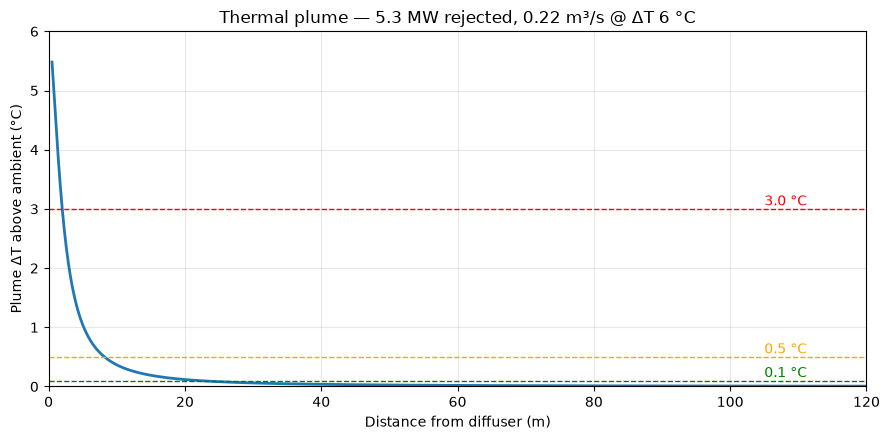

ΔT < 3.0 °C (reg limit) beyond: 2.3 m
ΔT < 0.5 °C beyond:             8.3 m
ΔT < 0.1 °C beyond:             22.1 m
-> Full compliance inside a 100 m mixing zone with large margin.

Freshwater avoided: 110,376 m³/yr (≈ 44 Olympic pools)
CO₂ avoided:        3,723 t/yr (≈ 809 cars)


In [4]:
# --- Thermal plume: near-field dilution from a multiport diffuser ---
# S(d) = bulk dilution at distance d; first-order model S = 1 + (d/d0)^1.7
# d0 = 2 m calibrated so S ~ 30 at 10 m (typical good diffuser in 0.3 m/s current)
d = np.linspace(0.5, 120, 400)
S = 1 + (d / 2.0) ** 1.7
dT_plume = P['discharge_dT_C'] / S

def dist_to(dT_lim):
    return d[np.argmax(dT_plume < dT_lim)]

d3, d05, d01 = dist_to(3.0), dist_to(0.5), dist_to(0.1)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(d, dT_plume, lw=2)
for lim, c in [(3.0, 'r'), (0.5, 'orange'), (0.1, 'g')]:
    ax.axhline(lim, color=c, ls='--', lw=1)
    ax.text(105, lim + 0.06, f'{lim} °C', color=c)
ax.set_xlabel('Distance from diffuser (m)')
ax.set_ylabel('Plume ΔT above ambient (°C)')
ax.set_title(f"Thermal plume — {heat_w/1e6:.1f} MW rejected, {flow_m3s:.2f} m³/s @ ΔT 6 °C")
ax.set_xlim(0, 120); ax.set_ylim(0, 6); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f"ΔT < 3.0 °C (reg limit) beyond: {d3:.1f} m")
print(f"ΔT < 0.5 °C beyond:             {d05:.1f} m")
print(f"ΔT < 0.1 °C beyond:             {d01:.1f} m")
print(f"-> Full compliance inside a {P['mixing_zone_m']} m mixing zone with large margin.")

# --- Freshwater saved (land evaporative WUE vs zero subsea) ---
water_saved_m3 = land_mwh * 1000 * P['wue_land_L_per_kwh'] / 1000
# --- Avoided carbon from cooling energy ---
co2_saved_t = saved_mwh * P['grid_co2_t_per_mwh']

print(f"\nFreshwater avoided: {water_saved_m3:,.0f} m³/yr (≈ {water_saved_m3/2500:.0f} Olympic pools)")
print(f"CO₂ avoided:        {co2_saved_t:,.0f} t/yr (≈ {co2_saved_t/4.6:,.0f} cars)")

### Qualitative ecological factors

| Factor | Subsea impact | vs Land |
|---|---|---|
| Thermal plume | +0.1 °C beyond ~22 m; negligible | Local heat-island from air cooling |
| Freshwater | Zero | ~110k m³/yr evaporated |
| Habitat | Artificial-reef colonization (observed on Natick); gravity-base footprint ~600 m² | Land take 1–2 ha + building |
| Noise | Pump/flow noise, low; masked by ambient beyond ~100 m | HVAC noise onshore |
| EMF | Shielded HV cable; subsea cable EMF measured low | – |
| Construction | One-time install: vessel emissions + turbidity (days) | Months of site construction |
| End of life | Full retrieval; no permanent seabed change | Brownfield site |
| Risk | Pod breach → server loss, inert N₂ release; no toxics | Refrigerant leaks (high GWP) |

## 5. Financial analysis

20-yr NPV of the subsea choice vs an equivalent land facility at the same IT capacity. Benefits: cooling energy + water savings. Costs: CAPEX premium, marine service operations, insurance/permitting premium.

,USD
Land CAPEX,"60,000,000"
Subsea CAPEX (+25%),"75,000,000"
CAPEX premium Δ,"15,000,000"
Energy savings /yr,"1,638,120"
Water savings /yr,"441,504"
Marine ops + insurance /yr,"850,000"
Net annual benefit,"1,229,624"
20-yr NPV of subsea choice,"-2,927,370"


Breakeven CAPEX premium: 20% (assumed 25%)


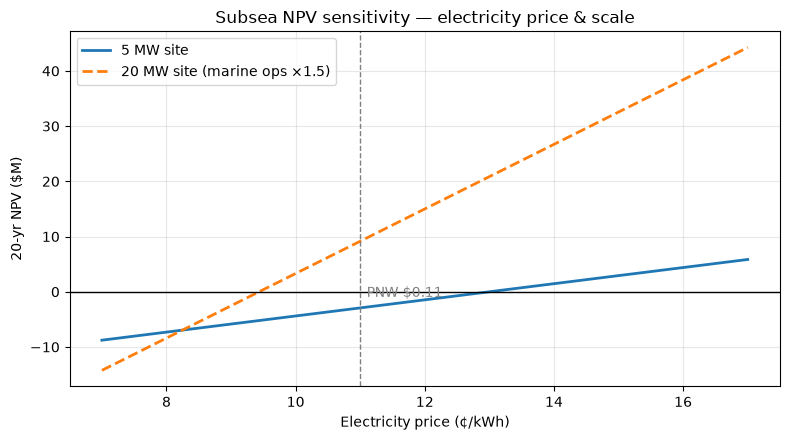

In [5]:
r, n = P['discount'], P['years']
af = (1 - (1 + r) ** -n) / r                     # annuity factor

# CAPEX
capex_land = P['it_load_mw'] * P['capex_land_per_mw']
capex_sea  = capex_land * (1 + P['capex_subsea_premium'])
capex_delta = capex_sea - capex_land

# Annual flows
energy_save_usd = saved_mwh * 1000 * P['elec_price_kwh']
water_save_usd  = water_saved_m3 * P['water_price_m3']
marine_annual   = P['service_event_cost'] / 5 + P['rov_annual'] + P['insurance_premium_annual']
net_annual      = energy_save_usd + water_save_usd - marine_annual

npv = net_annual * af - capex_delta
breakeven_premium = net_annual * af / capex_land

fin = pd.DataFrame({
    'USD': [capex_land, capex_sea, capex_delta, energy_save_usd, water_save_usd,
            marine_annual, net_annual, npv],
}, index=['Land CAPEX', 'Subsea CAPEX (+25%)', 'CAPEX premium Δ',
          'Energy savings /yr', 'Water savings /yr', 'Marine ops + insurance /yr',
          'Net annual benefit', '20-yr NPV of subsea choice'])
fin['USD'] = fin['USD'].map('{:,.0f}'.format)
display(fin)
print(f"Breakeven CAPEX premium: {breakeven_premium*100:.0f}% (assumed 25%)")

# Sensitivity: NPV vs electricity price, at 5 MW and 20 MW scale
prices = np.linspace(0.07, 0.17, 50)
npv_p5  = [(saved_mwh*1000*pr + water_save_usd - marine_annual) * af - capex_delta for pr in prices]
npv_p20 = [((saved_mwh*4)*1000*pr + water_save_usd*4 - marine_annual*1.5) * af - capex_delta*4 for pr in prices]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(prices*100, np.array(npv_p5)/1e6, lw=2, label='5 MW site')
ax.plot(prices*100, np.array(npv_p20)/1e6, lw=2, ls='--', label='20 MW site (marine ops ×1.5)')
ax.axhline(0, color='k', lw=1)
ax.axvline(P['elec_price_kwh']*100, color='gray', ls='--', lw=1)
ax.text(P['elec_price_kwh']*100 + 0.1, npv/1e6 + 2, 'PNW $0.11', color='gray')
ax.set_xlabel('Electricity price (¢/kWh)')
ax.set_ylabel('20-yr NPV ($M)')
ax.set_title('Subsea NPV sensitivity — electricity price & scale')
ax.grid(alpha=0.3); ax.legend()
plt.tight_layout(); plt.show()

## 6. Verdict

**Ecological: YES — net favorable.**
- Thermal signature is trivial: < 0.1 °C beyond ~22 m (consistent with Natick-area measurements)
- Zero freshwater consumption (~110k m³/yr avoided) and ~3,700 t CO₂/yr avoided vs a PUE-1.4 land site
- Small seabed footprint with a likely net-positive artificial-reef effect; fully retrievable at end of life
- Caveats: siting must avoid eelgrass beds / migration corridors; one-time construction disturbance; permitting (Army Corps, state aquatics, ESA review) is slow

**Financial: MARGINAL at 5 MW — only under the right conditions.**
- NPV ≈ **−$3M** over 20 yr at PNW power prices — cheap hydro electricity shrinks the cooling-energy savings that must pay for the marine CAPEX premium
- Breakeven: electricity ≳ **13 ¢/kWh**, or CAPEX premium ≲ **20%**, or scale ≳ **15–20 MW** (marine fixed costs amortize)
- Not counted (would improve the case): Natick-class reliability (1/8 failure rate → fewer server replacements), zero metro land cost, water-scarcity pricing, carbon credits

**Where it makes sense:** expensive-power, water-scarce, land-constrained coastal metros (Singapore, Hong Kong, SF Bay, Tokyo) at ≥ 10–20 MW scale. In the PNW it is an ecological win but a financial wash.

**Biggest unknowns:** marine insurance norms, permitting timeline cost, long-term biofouling of heat exchangers, cable-landing cost.